In [ ]:
# cell 1
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.ticker as mticker

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler

In [ ]:
# cell 2
# Settings
DATA_DIR = r"..\Data\model_data"
RESULTS_DIR = r"..\Results\Model_selection"
RESULTS_SAVE = r"..\Results"

SEED = 10
N_REPEATS = 1000
TOP_N = 10

OUTCOME_PREFIXES = [
    "mask",
    "protective",
    "social_avoidance"
]

In [ ]:
# cell 3
# Load data and best parameters
def load_training_data(prefix):
    X_train = pd.read_csv(f"{DATA_DIR}\\{prefix}_X_train.csv")
    y_train = pd.read_csv(f"{DATA_DIR}\\{prefix}_y_train.csv").values.ravel()

    return X_train, y_train


def prepare_X(X):
    X = X.copy()

    bool_cols = X.select_dtypes(include=["bool"]).columns

    if len(bool_cols) > 0:
        X[bool_cols] = X[bool_cols].astype(int)

    return X


def load_best_params(model_type):
    if model_type == "rf":
        file_name = "rf_cv_comparison.csv"
    elif model_type == "xgb":
        file_name = "xgb_cv_comparison.csv"
    else:
        raise ValueError("model_type must be 'rf' or 'xgb'")

    comparison_df = pd.read_csv(f"{RESULTS_DIR}\\{file_name}")

    best_params = {}

    for _, row in comparison_df.iterrows():
        outcome = row["outcome"]
        params = ast.literal_eval(row["best_params"])
        best_params[outcome] = params

    return best_params

In [ ]:
# cell 4
# Feature importance collection
def collect_feature_importance(prefix, model_type, params, n_repeats=200):
    X_train, y_train = load_training_data(prefix)

    X_train = prepare_X(X_train)
    feature_names = X_train.columns.tolist()

    importance_records = []

    for i in range(n_repeats):
        repeat_seed = SEED + i

        upsampler = RandomOverSampler(random_state=repeat_seed)
        X_up, y_up = upsampler.fit_resample(X_train, y_train)

        if not isinstance(X_up, pd.DataFrame):
            X_up = pd.DataFrame(
                X_up,
                columns=feature_names
            )

        if model_type == "rf":
            model = RandomForestClassifier(
                n_estimators=250,
                bootstrap=True,
                random_state=repeat_seed,
                n_jobs=-1,
                **params
            )

        elif model_type == "xgb":
            model = XGBClassifier(
                n_estimators=250,
                objective="binary:logistic",
                eval_metric="auc",
                random_state=repeat_seed,
                tree_method="hist",
                **params
            )

        else:
            raise ValueError("model_type must be 'rf' or 'xgb'")

        model.fit(X_up, y_up)

        fold_df = pd.DataFrame({
            "feature": feature_names,
            "importance": model.feature_importances_,
            "repeat": i + 1
        })

        importance_records.append(fold_df)

        if (i + 1) % 20 == 0:
            print(f"{model_type.upper()} | {prefix}: finished {i + 1} / {n_repeats}")

    importance_df = pd.concat(
        importance_records,
        ignore_index=True
    )

    return importance_df

In [ ]:
# cell 5
# Summarise importance
def remove_state_features(importance_df):
    return importance_df[
        ~importance_df["feature"].str.contains("state_", case=False, na=False)
    ].copy()


def summarize_importance(importance_df, top_n=10):
    summary = (
        importance_df
        .groupby("feature")["importance"]
        .agg(
            median_importance="median",
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75)
        )
        .reset_index()
    )

    summary["iqr"] = summary["q3"] - summary["q1"]

    summary = summary.sort_values(
        by="median_importance",
        ascending=False
    ).reset_index(drop=True)

    return summary.head(top_n)


def build_mirrored_rf_xgb_table(imp_rf, imp_xgb, top_n=10):
    rf_full = summarize_importance(
        remove_state_features(imp_rf),
        top_n=1000
    )

    xgb_full = summarize_importance(
        remove_state_features(imp_xgb),
        top_n=1000
    )

    rf_top = rf_full.head(top_n).copy()
    xgb_top = xgb_full.head(top_n).copy()

    feature_union = sorted(
        set(rf_top["feature"]) | set(xgb_top["feature"])
    )

    rows = []

    for feat in feature_union:
        row = {"feature": feat}

        if feat in set(rf_top["feature"]):
            rf_row = rf_top[rf_top["feature"] == feat].iloc[0]
            row["median_importance_rf"] = rf_row["median_importance"]
            row["q1_rf"] = rf_row["q1"]
            row["q3_rf"] = rf_row["q3"]
        else:
            row["median_importance_rf"] = 0.0
            row["q1_rf"] = 0.0
            row["q3_rf"] = 0.0

        if feat in set(xgb_top["feature"]):
            xgb_row = xgb_top[xgb_top["feature"] == feat].iloc[0]
            row["median_importance_xgb"] = xgb_row["median_importance"]
            row["q1_xgb"] = xgb_row["q1"]
            row["q3_xgb"] = xgb_row["q3"]
        else:
            row["median_importance_xgb"] = 0.0
            row["q1_xgb"] = 0.0
            row["q3_xgb"] = 0.0

        row["max_importance"] = max(
            row["median_importance_rf"],
            row["median_importance_xgb"]
        )

        rows.append(row)

    merged = pd.DataFrame(rows)

    merged = merged.sort_values(
        "max_importance",
        ascending=True
    ).reset_index(drop=True)

    return merged

In [ ]:
# cell 6
# Readable labels and categories
rename_map = {
    # Core policy and epidemic variables
    "H6M_Facial Coverings": "Facial Covering Policy",
    "C1M_School closing": "School Closing Policy",
    "C2M_Workplace closing": "Workplace Closing Policy",
    "cases_14d_avg": "14-day Average Cases",
    "deaths_14d_avg": "14-day Average Deaths",

    # Time
    "week_number": "Week Number",

    # Demographics
    "age": "Age",
    "household_size": "Household Size",

    # Behavioural context
    "protective_behaviour_nomask_scale": "Protective Behaviour",
    "non_household_contact": "Non-Household Contact",

}


def get_readable_feature(feature):
    if feature in rename_map:
        return rename_map[feature]

    readable = feature

    readable = readable.replace("_", " ")
    readable = readable.replace(".", " ")
    readable = readable.strip()

    return readable


def assign_category(readable_feature):
    name = readable_feature.lower()

    if "facial covering policy" in name:
        return "Policy"

    if "school closing policy" in name:
        return "Policy"

    if "workplace closing policy" in name:
        return "Policy"

    if "case" in name or "death" in name:
        return "Epidemic severity"

    if "week number" in name:
        return "Time"

    if "age" in name or "gender" in name or "employment" in name or "household" in name:
        return "Demographics"

    if "phq" in name or "cantril" in name or "wellbeing" in name or "comorbid" in name or "health" in name:
        return "Health, mental health and wellbeing"

    if "severity" in name or "suscept" in name or "dangerous" in name or "threat" in name or "risk" in name:
        return "Perception of illness threat"

    if "government" in name or "confidence" in name or "trust" in name or "satisfaction" in name:
        return "Trust in government"

    if "protective" in name or "isolate" in name or "contact" in name or "avoid" in name:
        return "Self-protective behaviours"

    return "Unclassified"


category_colors = {
    "Self-protective behaviours": "#0B6FA4",
    "Demographics": "#2E8BC0",
    "Health, mental health and wellbeing": "#6BAED6",
    "Perception of illness threat": "#B8AF9D",
    "Time": "#D98B36",
    "Trust in government": "#C76E00",
    "Policy": "#7A4EAB",
    "Epidemic severity": "#8C564B",
    "Unclassified": "#999999"
}


def apply_readable_labels_and_categories(mirror_df):
    df = mirror_df.copy()

    df["readable_feature"] = df["feature"].apply(get_readable_feature)
    df["category"] = df["readable_feature"].apply(assign_category)
    df["color"] = df["category"].map(category_colors).fillna("#999999")

    return df

In [ ]:
# cell 7
# Plotting function
def plot_mirrored_rf_xgb_colored(df, title):
    fig, ax = plt.subplots(figsize=(16, 10))

    y = np.arange(len(df))

    rf_vals = -df["median_importance_rf"].values
    xgb_vals = df["median_importance_xgb"].values

    rf_err_left = (
        df["q3_rf"] - df["median_importance_rf"]
    ).values

    rf_err_right = (
        df["median_importance_rf"] - df["q1_rf"]
    ).values

    xgb_err_left = (
        df["median_importance_xgb"] - df["q1_xgb"]
    ).values

    xgb_err_right = (
        df["q3_xgb"] - df["median_importance_xgb"]
    ).values

    colors = df["color"].tolist()

    ax.barh(
        y,
        rf_vals,
        xerr=[rf_err_left, rf_err_right],
        capsize=4,
        color=colors,
        error_kw={"elinewidth": 1.2, "capthick": 1.2}
    )

    ax.barh(
        y,
        xgb_vals,
        xerr=[xgb_err_left, xgb_err_right],
        capsize=4,
        color=colors,
        error_kw={"elinewidth": 1.2, "capthick": 1.2}
    )

    ax.set_yticks(y)
    ax.set_yticklabels(df["readable_feature"], fontsize=12)

    ax.axvline(0, color="black", linewidth=1)

    ax.set_xlabel("Median feature importance", fontsize=13)
    ax.set_title(title, fontsize=16, pad=35)

    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=11)

    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, pos: f"{abs(x):.2f}")
    )

    ax.text(
        0.25,
        1.03,
        "Random Forest",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=14
    )

    ax.text(
        0.75,
        1.03,
        "XGBoost",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=14
    )

    legend_order = [
        "Self-protective behaviours",
        "Demographics",
        "Health, mental health and wellbeing",
        "Perception of illness threat",
        "Time",
        "Trust in government",
        "Policy",
        "Epidemic severity",
        "Unclassified"
    ]

    handles = [
        Patch(facecolor=category_colors[c], label=c)
        for c in legend_order
        if c in df["category"].values
    ]

    ax.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.3),
        ncol=2,
        fontsize=11,
        frameon=False
    )

    plt.subplots_adjust(
        left=0.28,
        right=0.97,
        top=0.86,
        bottom=0.3
    )

    plt.show()

In [ ]:
# cell 8
# Run feature importance
best_rf_params = load_best_params("rf")
best_xgb_params = load_best_params("xgb")

importance_results = {}

for prefix in OUTCOME_PREFIXES:
    print("\n" + "=" * 60)
    print(f"Running feature importance for outcome: {prefix}")

    imp_rf = collect_feature_importance(
        prefix=prefix,
        model_type="rf",
        params=best_rf_params[prefix],
        n_repeats=N_REPEATS
    )

    imp_xgb = collect_feature_importance(
        prefix=prefix,
        model_type="xgb",
        params=best_xgb_params[prefix],
        n_repeats=N_REPEATS
    )

    mirror_table = build_mirrored_rf_xgb_table(
        imp_rf=imp_rf,
        imp_xgb=imp_xgb,
        top_n=TOP_N
    )

    mirror_table_labeled = apply_readable_labels_and_categories(
        mirror_table
    )

    importance_results[prefix] = {
        "rf_long": imp_rf,
        "xgb_long": imp_xgb,
        "mirror_table": mirror_table,
        "mirror_table_labeled": mirror_table_labeled
    }

    mirror_table_labeled.to_csv(
        f"{RESULTS_SAVE}\\feature_importance_{prefix}_rf_xgb_top10.csv",
        index=False
    )


Running feature importance for outcome: mask
RF | mask: finished 20 / 1000
RF | mask: finished 40 / 1000
RF | mask: finished 60 / 1000
RF | mask: finished 80 / 1000
RF | mask: finished 100 / 1000
RF | mask: finished 120 / 1000
RF | mask: finished 140 / 1000
RF | mask: finished 160 / 1000
RF | mask: finished 180 / 1000
RF | mask: finished 200 / 1000
RF | mask: finished 220 / 1000
RF | mask: finished 240 / 1000
RF | mask: finished 260 / 1000
RF | mask: finished 280 / 1000
RF | mask: finished 300 / 1000
RF | mask: finished 320 / 1000
RF | mask: finished 340 / 1000
RF | mask: finished 360 / 1000
RF | mask: finished 380 / 1000
RF | mask: finished 400 / 1000
RF | mask: finished 420 / 1000
RF | mask: finished 440 / 1000
RF | mask: finished 460 / 1000
RF | mask: finished 480 / 1000
RF | mask: finished 500 / 1000
RF | mask: finished 520 / 1000
RF | mask: finished 540 / 1000
RF | mask: finished 560 / 1000
RF | mask: finished 580 / 1000
RF | mask: finished 600 / 1000
RF | mask: finished 620 / 10

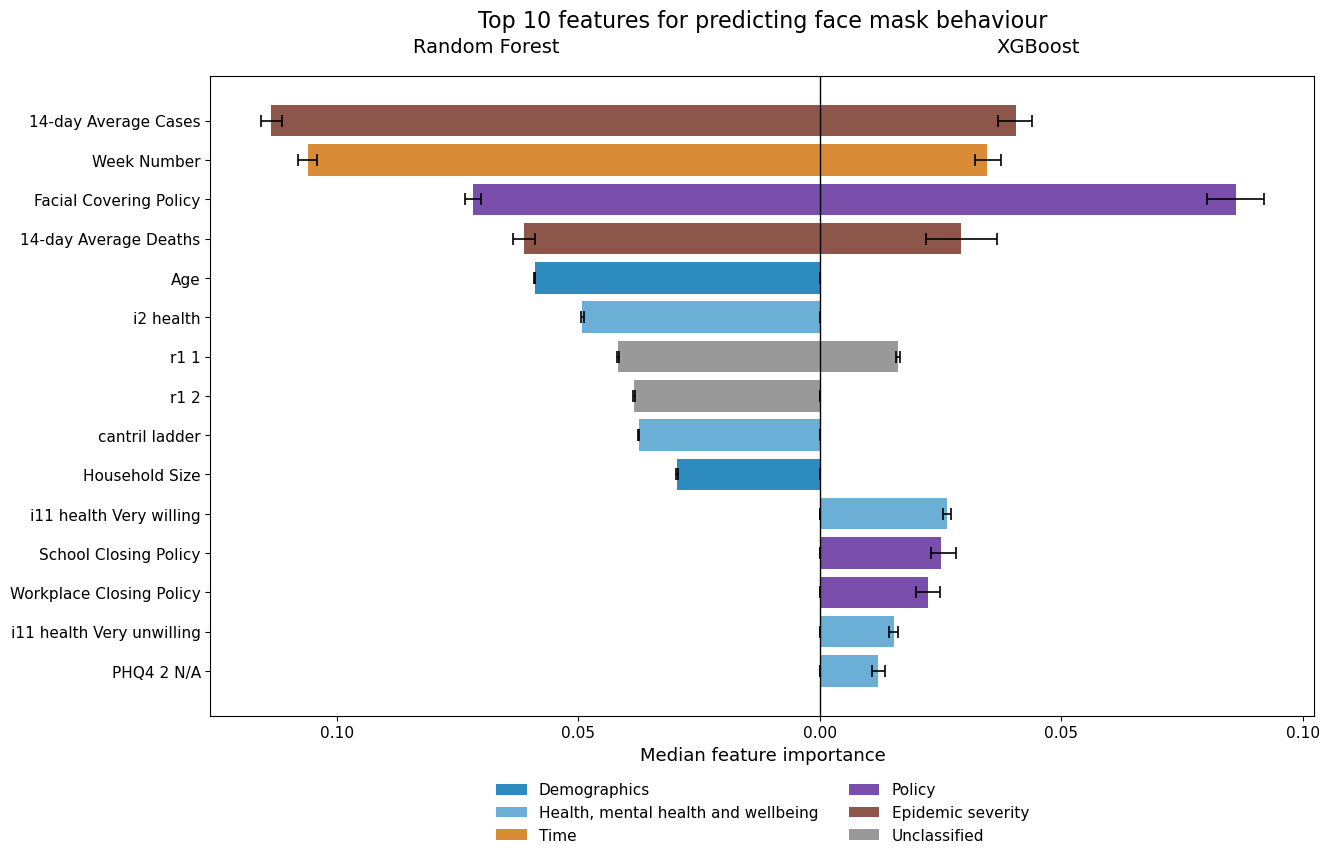

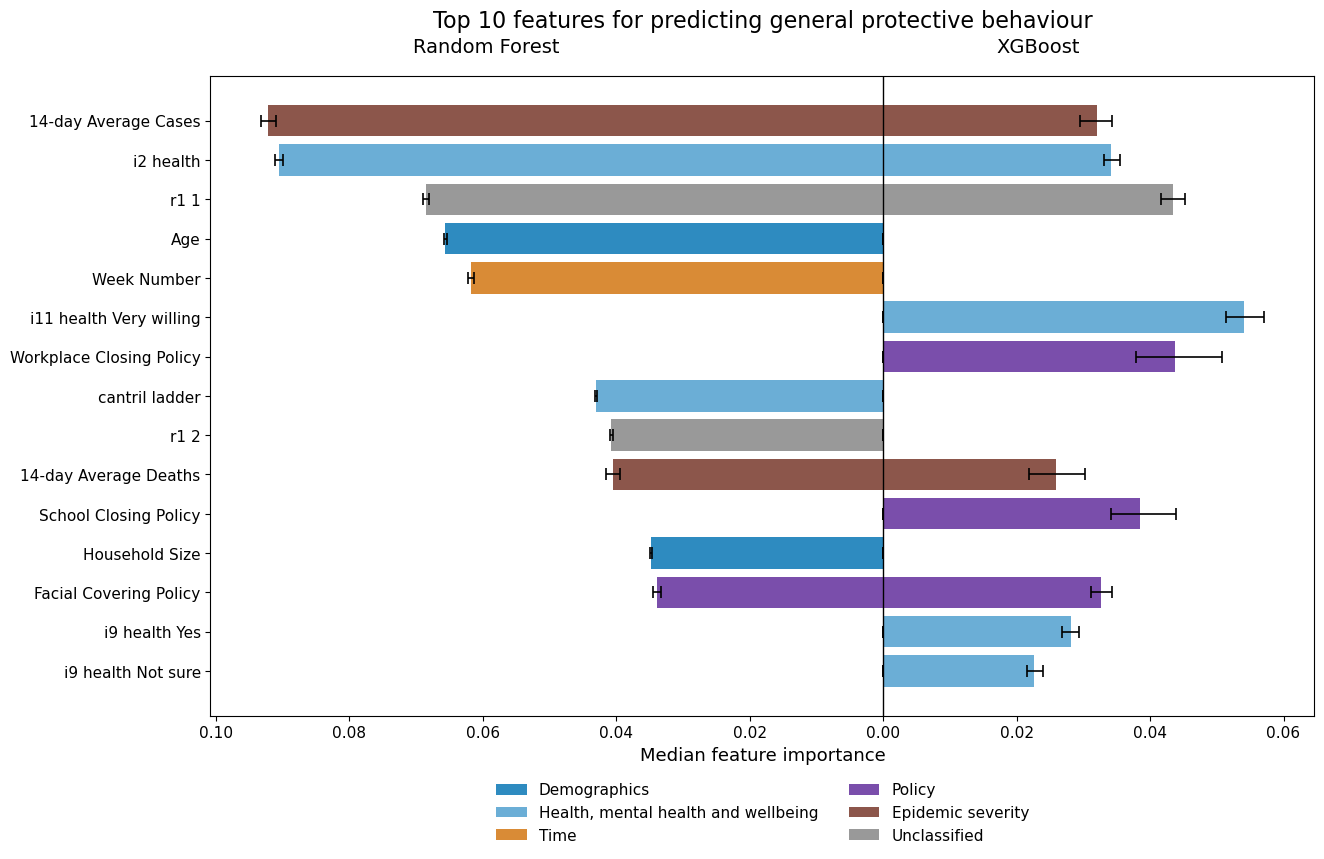

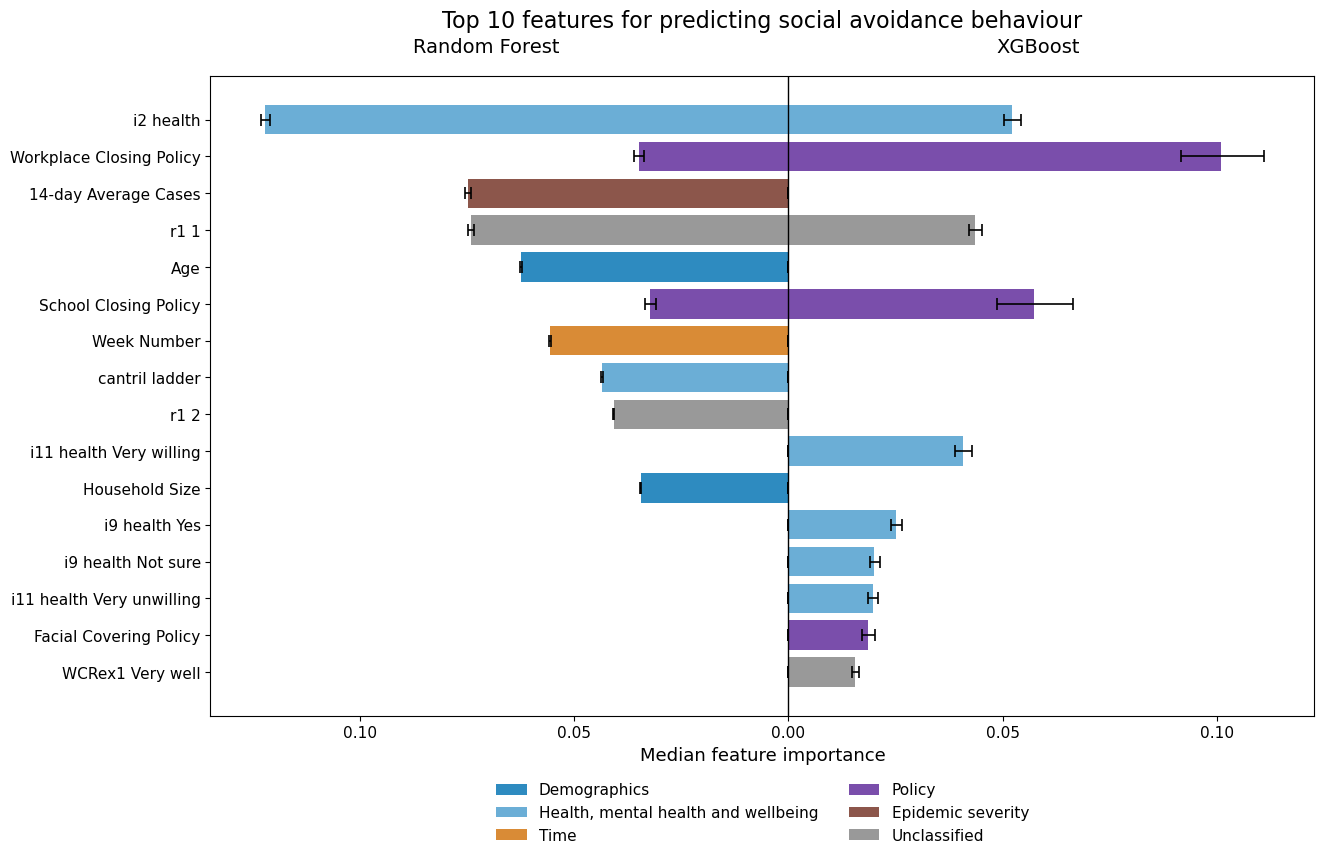

In [ ]:
# cell 9
plot_mirrored_rf_xgb_colored(
    importance_results["mask"]["mirror_table_labeled"],
    "Top 10 features for predicting face mask behaviour"
)

plot_mirrored_rf_xgb_colored(
    importance_results["protective"]["mirror_table_labeled"],
    "Top 10 features for predicting general protective behaviour"
)

plot_mirrored_rf_xgb_colored(
    importance_results["social_avoidance"]["mirror_table_labeled"],
    "Top 10 features for predicting social avoidance behaviour"
)

In [ ]:
# cell 10
# Improved readable labels
rename_map = {
    # Policy variables
    "H6M_Facial Coverings": "Facial covering policy",
    "C1M_School closing": "School closing policy",
    "C2M_Workplace closing": "Workplace restriction policy",

    # Epidemic severity variables
    "cases_14d_avg": "Average cases",
    "deaths_14d_avg": "Average deaths",

    # Time
    "week_number": "Week number",

    # Demographics
    "age": "Age",
    "household_size": "Household size",

    # Health, mental health and wellbeing
    "i2_health": "Non-household contacts",
    "cantril_ladder": "Cantril ladder",
    "PHQ4_2_N/A": "Feeling nervous or anxious: N/A",

    # Perception of illness threat
    "r1_1": "Perceived severity",
    "r1_2": "Perceived susceptibility",

    # Trust in government
    "WCRex1_Very well": "Satisfaction with government handling: very well",

    # Self-protective behaviours
    "i9_health_Yes": "Isolate if unwell: Yes",
    "i9_health_Not sure": "Isolate if unwell: Not sure",
    "i11_health_Very willing": "Very willing to isolate",
    "i11_health_Very unwilling": "Very unwilling to isolate"
}



category_map = {
    # Policy variables
    "Facial covering policy": "Policy",
    "School closing policy": "Policy",
    "Workplace restriction policy": "Policy",

    # Epidemic severity variables
    "Average cases": "Epidemic severity",
    "Average deaths": "Epidemic severity",

    # Time
    "Week number": "Time",

    # Demographics
    "Age": "Demographics",
    "Household size": "Demographics",

    # Health, mental health and wellbeing
    "Non-household contacts": "Health, mental health and wellbeing",
    "Cantril ladder": "Health, mental health and wellbeing",
    "Feeling nervous or anxious: N/A": "Health, mental health and wellbeing",

    # Perception of illness threat
    "Perceived severity": "Perception of illness threat",
    "Perceived susceptibility": "Perception of illness threat",

    # Trust in government
    "Satisfaction with government handling: very well": "Trust in government",

    # Self-protective behaviours
    "Isolate if unwell: Yes": "Self-protective behaviours",
    "Isolate if unwell: Not sure": "Self-protective behaviours",
    "Very willing to isolate": "Self-protective behaviours",
    "Very unwilling to isolate": "Self-protective behaviours"
}


category_colors = {
    "Self-protective behaviours": "#0B6FA4",
    "Demographics": "#2E8BC0",
    "Health, mental health and wellbeing": "#6BAED6",
    "Perception of illness threat": "#B8AF9D",
    "Time": "#D98B36",
    "Trust in government": "#C76E00",
    "Policy": "#7A4EAB",
    "Epidemic severity": "#8C564B",
    "Unclassified": "#999999"
}


def get_readable_feature(feature):
    return rename_map.get(feature, feature)


def apply_readable_labels_and_categories(mirror_df):
    df = mirror_df.copy()

    df["readable_feature"] = df["feature"].apply(get_readable_feature)
    df["category"] = df["readable_feature"].map(category_map).fillna("Unclassified")
    df["color"] = df["category"].map(category_colors).fillna("#999999")

    return df


In [ ]:
# cell 11
mask_table = pd.read_csv(f"{RESULTS_SAVE}\\feature_importance_mask_rf_xgb_top10.csv")
protective_table = pd.read_csv(f"{RESULTS_SAVE}\\feature_importance_protective_rf_xgb_top10.csv")
social_table = pd.read_csv(f"{RESULTS_SAVE}\\feature_importance_social_avoidance_rf_xgb_top10.csv")

mask_table_labeled = apply_readable_labels_and_categories(mask_table)
protective_table_labeled = apply_readable_labels_and_categories(protective_table)
social_table_labeled = apply_readable_labels_and_categories(social_table)

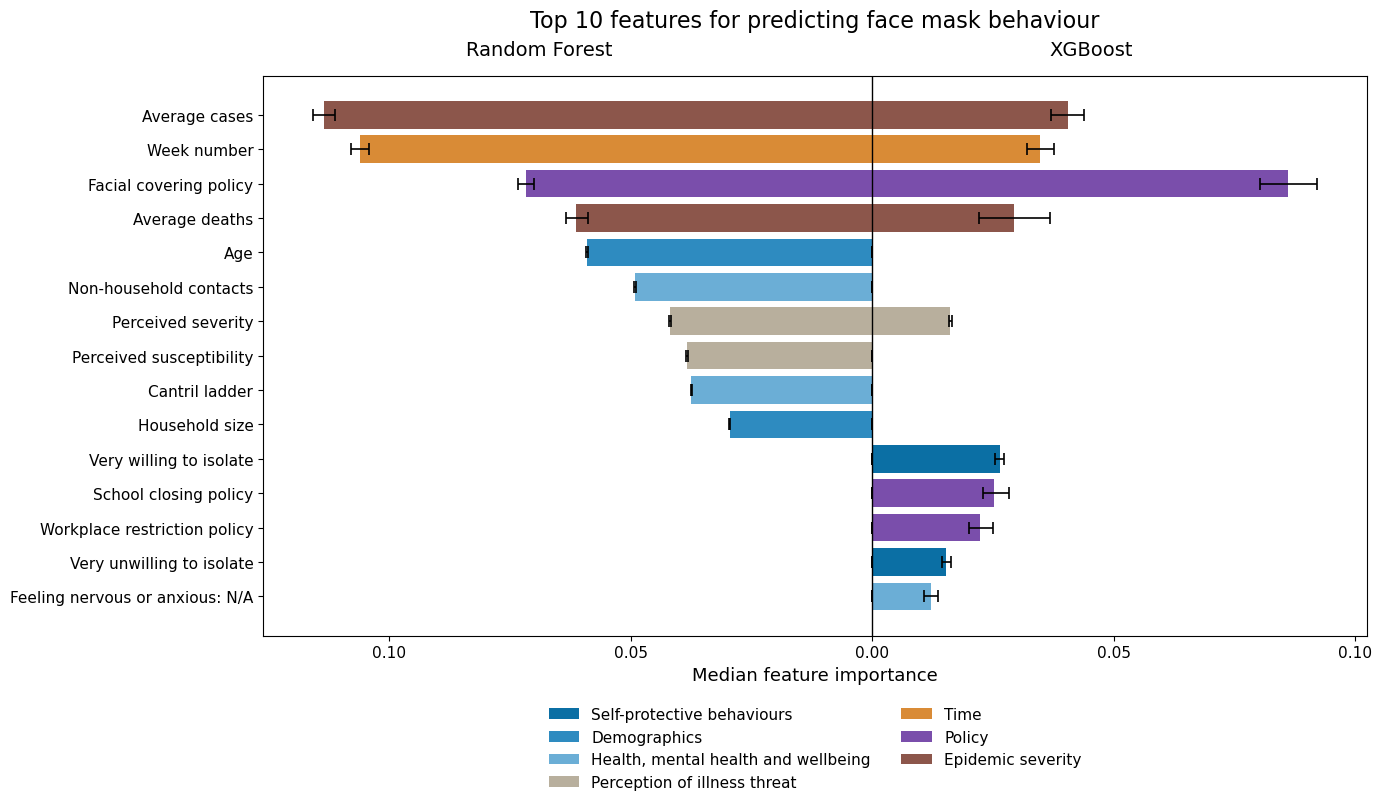

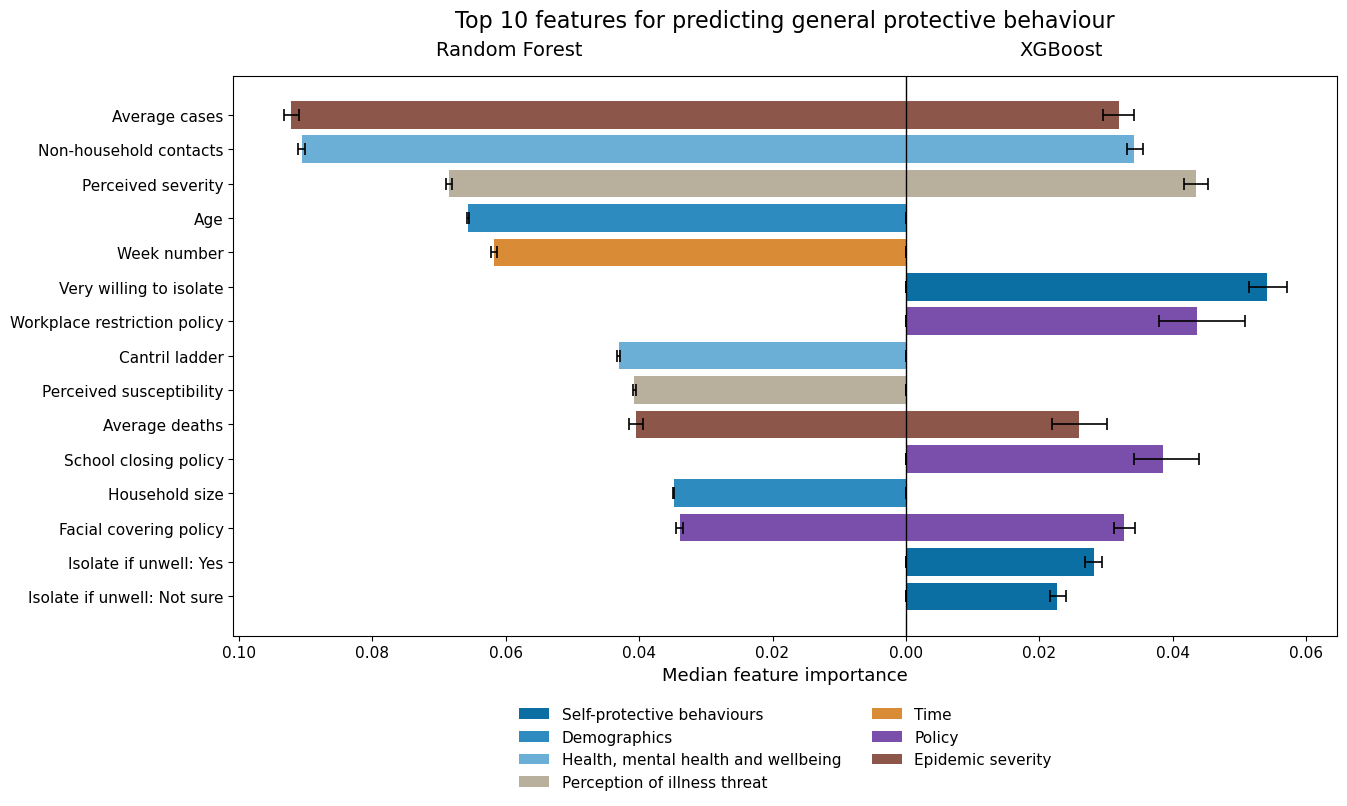

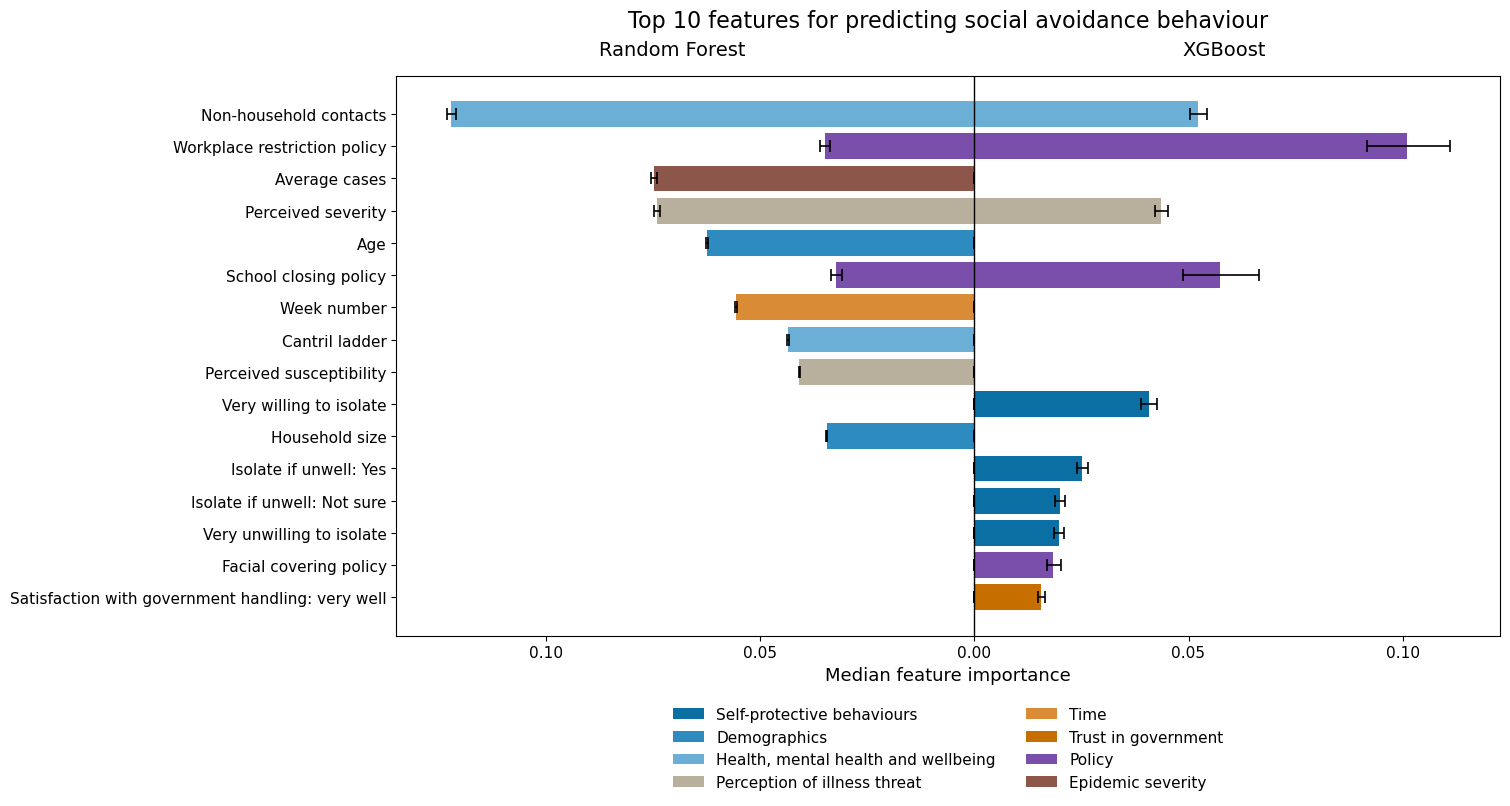

In [ ]:
# cell 12
plot_mirrored_rf_xgb_colored(
    mask_table_labeled,
    "Top 10 features for predicting face mask behaviour"
)

plot_mirrored_rf_xgb_colored(
    protective_table_labeled,
    "Top 10 features for predicting general protective behaviour"
)

plot_mirrored_rf_xgb_colored(
    social_table_labeled,
    "Top 10 features for predicting social avoidance behaviour"
)